# CHILI Case 2: TRAPPIST1-e

In [1]:
import sys
sys.path.append('/home/maxime/Models/MOAI/src')

from physics import eos,viscosity
from physics.phase_change.refractories import mc_book
from chemistry.elements import *
from chemistry.molecules import *
from chemistry.equilibria import *
from chemistry.redox import *
from magma_ocean import magma_ocean
from atmospheres import multi_species_single_condensible_convective_atmosphere as atmosphere
from utils import y2s
import matplotlib.pyplot as plt

import exo_k as xk
xk.Settings().set_mks(True)
xk_datapath = '/home/maxime/Models/Radiative_Transfer/data/'

%matplotlib inline

eq_C.coefs[O2]      = 0
eq_H.coefs[O2]      = 0

## Inputs

In [18]:
Rp          = 6.3781e6 # planetary radius             [m]  from CHILI Protocol paper
Rc          = 0.55*Rp  # core radius                  [m]  from CHILI Protocol paper
g           = 9.81     # surface gravity              [m/s^2]
T0          = 3000.    # initialpotential temperature [K]
p_CMB       = 135e9    # CMB pressure                 [Pa]

semimajor_axis      = 2.925e-2 # [AU]
Bond_albedo         = 0.1   # [-]     from CHILI Protocol paper
flux1AU             = 0.753 # [W/m^2] from CHILI Protocol paper
stellar_irradiation = 1./4*flux1AU/semimajor_axis**2*(1.-Bond_albedo)

M_ini = {'H2O':4.2e21,'CO2':1e21}

## Stellar evolution

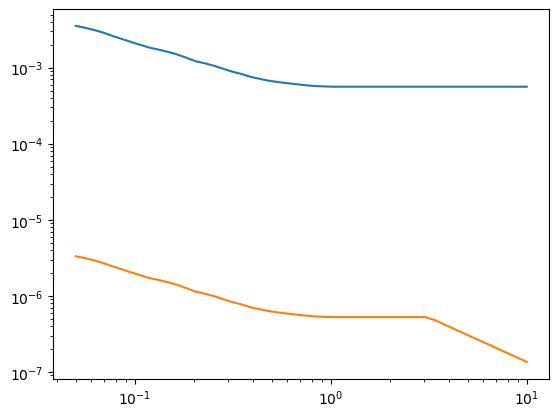

In [4]:
star_age,relative_bolometric_luminosity = np.genfromtxt('../TRAPPIST-1_evol_BHAC2015.txt',skip_header=1,unpack=True)

from scipy.interpolate import interp1d
get_relative_bolometric_luminosity = interp1d(star_age,10**relative_bolometric_luminosity)

plt.loglog(np.logspace(np.log10(50/1000),1),get_relative_bolometric_luminosity(np.logspace(np.log10(50/1000),1)))

f_sat = 10**(-3.03)    # [-] (Birky+ 2021)
t_sat = 3.14     # [Gyr] (Birky+ 2021)
beta_XUV = 1.17 # [-] (Birky+ 2021)

def get_relative_XUV_luminosity(t_Gyr):
    if t_Gyr<t_sat:
        return f_sat
    else:
        return f_sat*(t_Gyr/t_sat)**(-beta_XUV)
get_relative_XUV_luminosity = np.vectorize(get_relative_XUV_luminosity)
    
plt.semilogx(np.logspace(np.log10(50/1000),1),get_relative_bolometric_luminosity(np.logspace(np.log10(50/1000),1)) \
                                             *get_relative_XUV_luminosity(np.logspace(np.log10(50/1000),1)))

## Model

### Thermal evolution model

In [5]:
# create MO
from physics.eos import eos_book
MO = magma_ocean(T0,
                 p_CMB,
                 #eos={'rho':eos_book['rho']['MK19l'],'alpha':eos_book['alpha']['N19'],'cp':eos_book['cp']['cst']},
                 g=g,
                 R=Rp,
                 ConvCum=True)

# add melting curves
from physics.phase_change.refractories import mc_book
MO.setMeltingCurves(mc_book['Earth'],RCMF=0.4)
#MO.updateT_pot(max(MO.T_pot_lookup))

No file found: calculating lookups, be patient it can take some time!


### Redox model

In [6]:
# Set Fe3*/FeT in MO
from chemistry.partition_coefficients import get_part_coef
Fe_ferrous.part_coef = 1
MO.setParametrization('D_Fe3+_profile',lambda var: get_part_coef(var['pressures'],'Fe3+','2000km'),['pressures'],ptype='profile',channel='')

def set_Fe_ferric_part_coef(MO):
    # integrate the D_Fe3+ profile over
    Fe_ferric.part_coef = MO.getAverage(MO.profiles['D_Fe3+_profile'],domain=[MO.p_bot,MO.p_liq],mass_weighted=True)
    if np.isnan(Fe_ferric.part_coef):
        Fe_ferric.part_coef = get_part_coef(MO.p_bot,'Fe3+','2000km')
    return Fe_ferric.part_coef
MO.setParametrization('D_Fe3+_eff', lambda var: set_Fe_ferric_part_coef(var['MO']),[],ptype='scalar')

BSE_Fe3p_FeT = 0.094 # 0.17 # 0.094 is tuned to have IW-4 when the potential temperature is 1600 K (8.7% MO remaining). 0.17 is tuned to have IW-4 at 1600 K when the MO is 660 km-de8
BSE_FeO      = 0.0583 # Sun and McDonnough 1995
MO.addSpecies([Fe_ferric,Fe_ferrous],
              [BSE_Fe3p_FeT*BSE_FeO,(1-BSE_Fe3p_FeT)*BSE_FeO])
MO.to_frac=['Fe3+','Fe2+']
MO.fractionation(MO.to_frac)
MO.setParametrization('Fe3+/FeT',lambda var:1/(1+1/(var['Fe3+_liquid']/var['Fe2+_liquid']*Fe_ferrous.molecular_mass/Fe_ferric.molecular_mass)),
                      ['Fe2+_liquid','Fe3+_liquid'],ptype='scalar')

# Set fO2
from physics.constants import BSE
MO.setParametrization('fO2_sfc',
                      lambda var: fO2_sfc_H22(var['T_pot'],var['Fe3+/FeT'],BSE),
                      ['T_pot','Fe3+/FeT'],
                      ptype='scalar')
from chemistry.redox import fO2_buffers_H22
MO.setParametrization('DeltaIW_sfc',
                      lambda var: np.log10(var['fO2_sfc'])-fO2_buffers_H22(var['p_sfc'],var['T_pot']),
                      ['T_pot','p_sfc','fO2_sfc'],
                      ptype='scalar')

/home/maxime/Models/MOAI/src/magma_ocean.py:895: RuntimeWarning: invalid value encountered in scalar divide
  return self.getIntegral(profile*self.profiles['rho'],domain=domain) / self.getIntegral(self.profiles['rho'],domain=domain)


### Chemical model

In [7]:
MO.setupChemistry({H2O:M_ini['H2O']/MO.M_system,
                   CO2:M_ini['CO2']/MO.M_system,
                   N2:1e-6,
                   S2:1e-6})
MO.speciationInit()

### Atmosphere

In [8]:
MO.atm = atmosphere(list(MO.atm.species.values()),
                    np.array([MO.atm.partial_pressure[sp.formula] for sp in list(MO.atm.species.values())]),
                    MO.adiabat.T_pot,R=MO.R_out,g=MO.gravity,pToA=1,cond=H2O,T_str=200.)

#### Use exo_k for radiative transfer

In [9]:
xk.Settings().add_search_path(xk_datapath + 'corrk',path_type='ktable')
corrk_database = xk.Kdatabase(['H2O','CO2','CO','NH3','CH4','H2S','HCN','SO2'])

In [10]:
wavenumber_grid=xk.wavenumber_grid_R(200.,10000.,10)
corrk_database.bin_down(wavenumber_grid)

xk.Settings().add_search_path(xk_datapath + 'cia',path_type='cia')
cia_database = xk.CIAdatabase(molecules=['H2'])
cia_database.sample(corrk_database.wns)

In [11]:
R = sum([8.314/(molecules_book[sp].molecular_mass/1000)*MO.atm.volume_mixing_ratio[sp] for sp in MO.atm.species])
cp = sum([molecules_book[sp].cp_mass(MO.atm.Ts)*MO.atm.volume_mixing_ratio[sp] for sp in MO.atm.species])
rcp = R/cp

logplay = np.log10(np.flipud(MO.atm.profiles['pressure']))
tlay    = np.flipud(MO.atm.profiles['temperature'])
clay    = {sp:np.flipud(MO.atm.profiles['molar fraction'][sp]) for sp in MO.atm.species}

MO.atm.radiation = xk.Atm(logplay=logplay,
                          tlay=tlay,
                          grav=MO.gravity, Rp=MO.R_out, rcp=rcp,
                          albedo_surf=Bond_albedo,
                          composition=clay,
                          k_database=corrk_database,
                          cia_database=cia_database,
                          rayleigh=True)

def getOLR():
    return MO.atm.radiation.emission_spectrum_2stream().total

MO.atm.getOLR = getOLR

In [12]:
def update_rad_pres(var):
    MO.atm.radiation.set_logPT_profile(np.log10(np.flipud(var['atm'].profiles['pressure'])),np.flipud(var['atm'].profiles['temperature']))
MO.setParametrization('radPres',update_rad_pres,['atm'],is_profile=False,channel='post-spec',ptype='action')  

/home/maxime/Models/MOAI/src/magma_ocean.py:895: RuntimeWarning: invalid value encountered in scalar divide
  return self.getIntegral(profile*self.profiles['rho'],domain=domain) / self.getIntegral(self.profiles['rho'],domain=domain)


In [13]:
MO.t = 50e6*y2s
solar_constant = 1334 # [W/m2] present-day value
def update_bolometric_luminosity(var):
    t_Gyr = var['t']/y2s/1e9
    return 1./4*solar_constant*get_relative_bolometric_luminosity(t_Gyr)/semimajor_axis**2*(1.-Bond_albedo)
MO.setParametrization('bolometric_irradiation',update_bolometric_luminosity,['t'],channel='post-spec',ptype='scalar')  

In [14]:
def flux_residual(MO,T):
    #print('Calculating flux residual for T_surf=',T)
    MO.atm.updateTs(T)
    MO.updateBL(MO.adiabat.T_pot-T)
    # now need to update composition (can be altered by condensation) and tempreature profiles
    MO.atm.radiation.set_gas({sp:np.flipud(MO.atm.profiles['molar fraction'][sp]) for sp in MO.atm.species})
    MO.atm.radiation.set_T_profile(np.flipud(MO.atm.profiles['temperature']))
    return MO.BL.getFlux()+MO.scalar['bolometric_irradiation']-MO.atm.getOLR()
MO.flux_residual = flux_residual

In [15]:
from scipy.constants import N_A
def atmospheric_escape(f_H2,dt,t,MO):
    t_Gyr = t/y2s/1e9
    L_XUV0 = -3.13 # present-day log10(L_XUV/L_bol) of the Sun
    S = get_relative_bolometric_luminosity(t_Gyr)*get_relative_XUV_luminosity(t_Gyr)/10**L_XUV0/semimajor_axis**2
    #S = 40 # F_XUV /F_XUV today
    phi_H2 = 2e16*f_H2*S/np.sqrt(1+0.006*S**2)/N_A # [mol/m^2/s] (valid for f_H2 < 0.2)
    MO.content['system']['H'] -= 4*np.pi*MO.R_out**2*phi_H2*dt*(2*H.atomic_mass)/MO.M_system
    #MO.tendencies['H_content'] = 4*np.pi*MO.R_out**2*phi_H2*dt*(2*H.atomic_mass)/MO.M_system / MO.content['system']['H']
    return phi_H2
MO.setParametrization('f_H2',lambda var:var['atm'].profiles['molar fraction']['H2'][-1],['atm'],is_profile=False,channel='post-spec',ptype='scalar')
MO.setParametrization('phi_H2',lambda var:atmospheric_escape(var['f_H2'],var['dt'],var['t'],var['MO']),['f_H2','t','dt'],is_profile=False,channel='time-dep',ptype='scalar')

In [20]:
MO.atm.stellar_irradiation = stellar_irradiation
MO.RK4_step(0,rtol=1e-7)
print(MO.BL.getFlux())

/home/maxime/Models/MOAI/src/magma_ocean.py:895: RuntimeWarning: invalid value encountered in scalar divide
  return self.getIntegral(profile*self.profiles['rho'],domain=domain) / self.getIntegral(self.profiles['rho'],domain=domain)


7444.452740872688


## Outputs
### CHILI format

In [21]:
from tools import time_series
ts=time_series(MO)

# Add custom quantities
ts.register('OLR','atm.getOLR()')                          # Save OLR
ts.register('mu_atm','atm.average_molecular_mass')         # Save average molecular mass of the atmosphere
ts.register('p_tot','atm.ps')                              # Save surface pressure
ts.register('p_cloud','atm.cloud_deck')                    # Save lifting condensation level
ts.register('T_bot','adiabat.getT(self.attribute.p_bot)')  # Save temperature at the bottom of the MO
ts.register('Ra','getRa(\'MO\')')                          # Save MO Rayleigh number
ts.register('phi_H2','scalar[\'phi_H2\']')                 # Save H2 escape flux
ts.register('Fconv','BL.getFlux()')                        # Save MO convective flux
ts.register('T_surf','atm.Ts')                             # Save surface temperature
ts.register('avg_melt_frac','averages[\'phi\']')           # Save average melt fraction

ts.write(0)

In [29]:
MO.max_dT=100000*y2s
#dt = 1000*y2s
dt /= 2.5

MO.max_change['Tpot']= 1
MO.min_T_surf = 1000

For the TRAPPIST-1b case you may have to decrease MO.max_dT as you approach the end of solidification because the equilibrium temperature is high until H2 escape has eroded the atmosphere and you need to approach it gently

In [30]:
ts2 = deepcopy(ts)
MO2 = deepcopy(MO)
#ts = deepcopy(ts2)
#MO = deepcopy(MO2)

In [31]:
while MO.M_system/ts('M_sys')[0] > 0.01:
#while MO.adiabat.T_pot > 1800:
    dt=MO.RK4_step(dt,rtol=1e-8)
    ts.write(MO.t)
    print('M/M0=',MO.M_system/ts('M_sys')[0])
    print('Tpot=',MO.adiabat.T_pot,'K')
    print('dt=',dt/y2s,'y')

M/M0= 0.08764719119173985
Tpot= 1797.4660764341847 K
dt= 594.0576718633769 y
M/M0= 0.0873175566649131
Tpot= 1796.4842191518276 K
dt= 605.0346445842094 y
M/M0= 0.0869847996055197
Tpot= 1795.4943516560163 K
dt= 611.2279139829272 y
M/M0= 0.08665163001426533
Tpot= 1794.5045499177795 K
dt= 617.5256017147329 y
M/M0= 0.08631807772469499
Tpot= 1793.5149046491708 K
dt= 623.9868176027853 y
M/M0= 0.08598409097296225
Tpot= 1792.5252659262349 K
dt= 630.5198080280635 y
M/M0= 0.08564969406718392
Tpot= 1791.5357079461983 K
dt= 637.1731831264979 y
M/M0= 0.08531489028779729
Tpot= 1790.5462418442714 K
dt= 643.9565558493579 y
M/M0= 0.08497966598595466
Tpot= 1789.5568291327825 K
dt= 650.8472636057713 y
M/M0= 0.08464404092904096
Tpot= 1788.5675301738863 K
dt= 657.8873431059831 y
M/M0= 0.08430800537557315
Tpot= 1787.578319678582 K
dt= 665.0630439413986 y
M/M0= 0.08397155816167112
Tpot= 1786.5891960331637 K
dt= 672.37604421056 y
M/M0= 0.08363470128093539
Tpot= 1785.6001662371661 K
dt= 679.833961455571 y
M/M0=

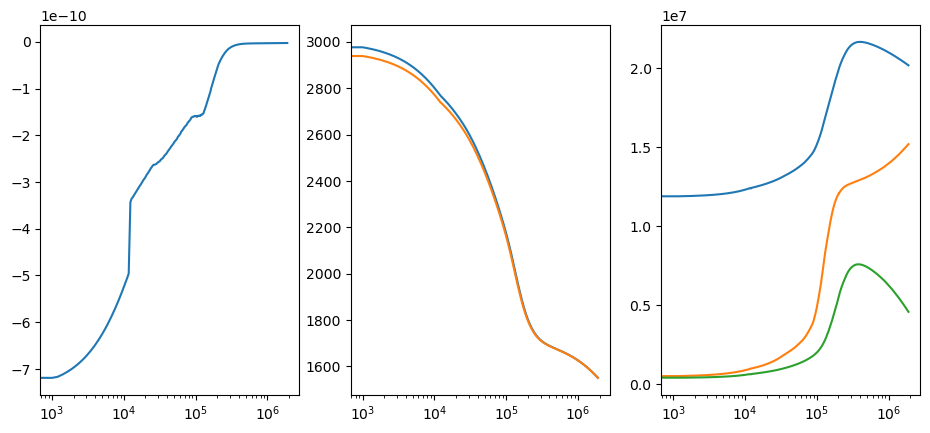

In [32]:
plt.subplot(131)
plt.semilogx(ts('time')/y2s-50e6,np.gradient(ts('T_pot'),ts('time')))
#plt.plot(ts2('time')/y2s,np.gradient(ts2('T_pot'),ts2('time')))
#plt.plot(ts3('time')/y2s,np.gradient(ts3('T_pot'),ts3('time')))

plt.subplot(132)
plt.semilogx(ts('time')/y2s-50e6,ts('T_pot'))
plt.plot(ts('time')/y2s-50e6,ts('T_surf'))
#plt.plot(ts2('time')/y2s,ts2('T_pot'))
#plt.plot(ts3('time')/y2s,ts3('T_pot'))

plt.subplot(133)
plt.semilogx(ts('time')/y2s-50e6,ts('p_tot'))
plt.plot(ts('time')/y2s-50e6,ts('p_CO2'))
plt.plot(ts('time')/y2s-50e6,ts('p_H2O'))

plt.subplots_adjust(right=1.5)

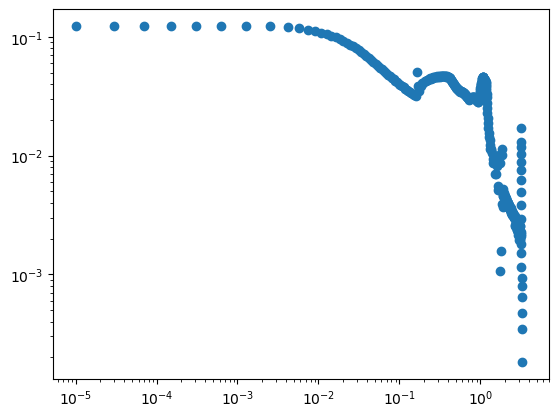

In [44]:
plt.scatter(ts('time')/y2s/1e6-50,(ts('OLR')-ts('bolometric_irradiation'))/ts('bolometric_irradiation'))
plt.yscale('log')
plt.xscale('log')

In [33]:
M_atm = 4*np.pi*MO.R_out**2/MO.gravity*sum([ts('p_'+str(sp)) for sp in MO.atm.species])

M_H_atm = M_atm*(ts('p_H2O')/ts('p_tot')*H2O.molecular_mass/ts('mu_atm')*2*H.atomic_mass/H2O.molecular_mass \
               + ts('p_H2')/ts('p_tot')*H2.molecular_mass/ts('mu_atm')*2*H.atomic_mass/H2.molecular_mass \
               + ts('p_CH4')/ts('p_tot')*CH4.molecular_mass/ts('mu_atm')*4*H.atomic_mass/CH4.molecular_mass)
M_C_atm = M_atm*(ts('p_CO2')/ts('p_tot')*CO2.molecular_mass/ts('mu_atm')*C.atomic_mass/CO2.molecular_mass \
               + ts('p_CO')/ts('p_tot')*CO.molecular_mass/ts('mu_atm')*C.atomic_mass/CO.molecular_mass \
               + ts('p_CH4')/ts('p_tot')*CH4.molecular_mass/ts('mu_atm')*C.atomic_mass/CH4.molecular_mass)

In [35]:
import pandas as pd
ts_pd = pd.DataFrame({'t(yr)':ts('t')/y2s,
                      'T_surf(K)':ts('T_pot'),
                      'T_pot(K)':ts('T_sfc'),
                      'flux_surf(W/m2)':ts('Fconv'),
                      'flux_OLR(W/m2)':ts('OLR'),
                      'flux_ASR(W/m2)':ts('bolometric_irradiation'),
                      'phi(vol_frac)':ts('phi_avg'),
                     #'fO2_solid(bar)':[],
                      'fO2_melt(bar)':ts('fO2_sfc'),
                     #'thick_surf_bl(m)':[],
                      'massC_solid(kg)':ts('C_solid')*ts('M_sol'),
                      'massC_melt(kg)':ts('C_liquid')*ts('M_liq'),
                      'massC_atm(kg)':M_H_atm,
                      'massH_solid(kg)':ts('H_solid')*ts('M_sol'),
                      'massH_melt(kg)':ts('H_liquid')*ts('M_liq'),
                      'massH_atm(kg)':M_C_atm,
                      'p_surf(bar)':ts('p_tot')*1e-5,
                      'p_H2O(bar)':ts('p_H2O')*1e-5,
                      'p_CO2(bar)':ts('p_CO2')*1e-5,
                      'p_CO(bar)':ts('p_CO')*1e-5,
                      'p_H2(bar)':ts('p_H2')*1e-5,
                      'p_CH4(bar)':ts('p_CH4')*1e-5,
                      'p_O2(bar)':ts('fO2_sfc'),
                      'mmw(kg/mol)':ts('mu_atm')*1e-3,
                      'R_solid(m)':np.ones_like(ts('t')*MO.R_out)})
ts_pd.to_csv('evolution-moai-trappist1-e.csv',index=None)